# KNN Live Coding Session (Iris Classification)

**A) PRE-WRITTEN Intro**

K-Nearest Neighbors (KNN) is a **lazy learning** algorithm:
- It does almost no work during "training" (it mainly stores examples).
- Most work happens at **prediction time** (distance checks to training points).

In this notebook we build KNN **from scratch** using plain Python lists/loops:
- Train/test split
- Min-max normalization
- Manhattan distance
- Neighbor selection + majority vote with deterministic tie-break
- Accuracy evaluation
- k sweep (1 to 31, odd k values) + plot

Cells are labeled either **PRE-WRITTEN** or **LIVE CODING**.

In [19]:
# PRE-WRITTEN
import random
import math
from sklearn.datasets import load_iris, make_regression

SEED = 42

## Environment check


In [20]:
# PRE-WRITTEN
import sys
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("sklearn.__version__:", sklearn.__version__)
print("matplotlib.__version__:", matplotlib.__version__)
print("Import test: sklearn.datasets and matplotlib.pyplot OK")


Python executable: /Users/nino/ML/.venv/bin/python
Python version: 3.14.0
sklearn.__version__: 1.8.0
matplotlib.__version__: 3.10.8
Import test: sklearn.datasets and matplotlib.pyplot OK


In [21]:
# PRE-WRITTEN
iris = load_iris()
X = iris.data.tolist()
y = iris.target.tolist()

print("Dataset size:", len(X))
print("Num features:", len(X[0]))
print("Unique classes:", sorted(set(y)))
print("First row (raw):", X[0])
print("First label:", y[0])

Dataset size: 150
Num features: 4
Unique classes: [0, 1, 2]
First row (raw): [5.1, 3.5, 1.4, 0.2]
First label: 0


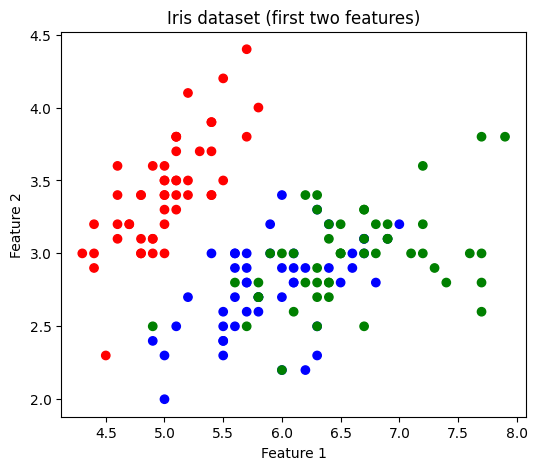

In [22]:
# PRE-WRITTEN
# VISUALIZATION

feature_1 = [row[0] for row in X]
feature_2 = [row[1] for row in X]

colors = []
for label in y:
    if label == 0:
        colors.append("red")
    elif label == 1:
        colors.append("blue")
    else:
        colors.append("green")

plt.figure(figsize=(6,5))
plt.scatter(feature_1, feature_2, c=colors)
plt.title("Iris dataset (first two features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## D) LIVE CODING Utilities

Implement these core functions from scratch.

In [23]:
# LIVE CODING
def train_test_split_py(X, y, test_size=0.3, seed=SEED):
    """
    Split X and y into train/test parts using shuffled indices.
    This gives us an unbiased held-out test set for evaluation.
    """
    n = len(X)
    indices = list(range(n))

    random.seed(seed)
    random.shuffle(indices)

    test_count = int(n * test_size)
    test_indices = indices[:test_count]
    train_indices = indices[test_count:]

    X_train, X_test, y_train, y_test = [], [], [], []

    for idx in train_indices:
        X_train.append(X[idx])
        y_train.append(y[idx])

    for idx in test_indices:
        X_test.append(X[idx])
        y_test.append(y[idx])

    return X_train, X_test, y_train, y_test

**CHECK (after implementation):**
- For Iris with `test_size=0.3`, you should get `105` train and `45` test rows.
- Labels should have matching lengths with feature rows.

In [24]:
# Quick sanity check
X_train, X_test, y_train, y_test = train_test_split_py(X, y, test_size=0.3, seed=SEED)
print("len(X_train):", len(X_train))
print("len(X_test):", len(X_test))
print("len(y_train):", len(y_train))
print("len(y_test):", len(y_test))
print("train lengths match:", len(X_train) == len(y_train))
print("test lengths match:", len(X_test) == len(y_test))


len(X_train): 105
len(X_test): 45
len(y_train): 105
len(y_test): 45
train lengths match: True
test lengths match: True


In [25]:
# LIVE CODING
def minmax_fit(X_train):
    """
    Compute per-feature minimum and maximum values on training data only.
    This prevents test-set information leakage.
    """
    num_features = len(X_train[0])
    mins = X_train[0][:]
    maxs = X_train[0][:]

    for row in X_train:
        for j in range(num_features):
            if row[j] < mins[j]:
                mins[j] = row[j]
            if row[j] > maxs[j]:
                maxs[j] = row[j]

    return mins, maxs

**CHECK (after implementation):**
- `mins` and `maxs` should each have length `4` for Iris.
- Each `mins[j] <= maxs[j]` for every feature index `j`.

In [26]:
# Quick sanity check
mins, maxs = minmax_fit(X_train)
print("mins:", mins)
print("maxs:", maxs)
print("len(mins):", len(mins))
print("len(maxs):", len(maxs))


mins: [4.3, 2.2, 1.0, 0.1]
maxs: [7.7, 4.4, 6.7, 2.5]
len(mins): 4
len(maxs): 4


In [27]:
# LIVE CODING
def minmax_transform(X, mins, maxs):
    """
    Scale each feature to [0, 1] using training mins/maxs.
    If a feature is constant (max == min), return 0.0 for that feature.
    """
    X_scaled = []
    num_features = len(mins)

    for row in X:
        new_row = []
        for j in range(num_features):
            min_v = mins[j]
            max_v = maxs[j]
            if max_v == min_v:
                new_row.append(0.0)
            else:
                scaled = (row[j] - min_v) / (max_v - min_v)
                new_row.append(scaled)
        X_scaled.append(new_row)

    return X_scaled

**CHECK (after implementation):**
- Scaled values should be between `0` and `1` (inclusive).
- The first training row before/after scaling should clearly change magnitude.

In [28]:
# Quick sanity check
X_train_scaled = minmax_transform(X_train, mins, maxs)
print("first raw train row:", X_train[0])
print("first scaled train row:", X_train_scaled[0])
print("global scaled min:", min(min(row) for row in X_train_scaled))
print("global scaled max:", max(max(row) for row in X_train_scaled))


first raw train row: [5.6, 3.0, 4.1, 1.3]
first scaled train row: [0.3823529411764705, 0.36363636363636354, 0.5438596491228069, 0.5]
global scaled min: 0.0
global scaled max: 1.0


In [29]:
# LIVE CODING
def manhattan_distance(a, b):
    """
    Compute Manhattan (L1) distance between two equal-length vectors.
    L1 distance is sum of absolute coordinate differences.
    """
    total = 0.0
    for i in range(len(a)):
        total += abs(a[i] - b[i])
    return total

In [30]:
# LIVE CODING
def euclidean_distance(a, b):
    """
    Compute Euclidean (L2) distance between two vectors.
    """
    total = 0.0
    for i in range(len(a)):
        diff = a[i] - b[i]
        total += diff * diff
    return math.sqrt(total)

In [31]:
# LIVE CODING
def distance(a, b, metric="manhattan"):
    """
    Select distance metric.
    """
    if metric == "manhattan":
        return manhattan_distance(a, b)
    elif metric == "euclidean":
        return euclidean_distance(a, b)
    else:
        raise ValueError("Unknown metric")

**CHECK (after implementation):**
- `manhattan_distance([0, 1], [2, 4])` should return `5.0`.

In [32]:
# Quick sanity check
print("manhattan_distance([0, 1], [2, 4]) =", manhattan_distance([0, 1], [2, 4]))
print("expected: 5.0")


manhattan_distance([0, 1], [2, 4]) = 5.0
expected: 5.0


In [33]:
# LIVE CODING
def knn_predict_one(x, X_train, y_train, k, metric="manhattan"):
    """
    Predict one class label using KNN with majority vote.

    Tie-break rule (deterministic):
    - If classes tie on vote count, choose the tied class whose single
      closest neighbor (among the k neighbors) has the smallest distance.
    - If still tied on distance, choose the smaller class id.
    """
    distance_label_pairs = []

    for i in range(len(X_train)):
        d = distance(x, X_train[i], metric)
        distance_label_pairs.append((d, y_train[i]))

    distance_label_pairs.sort(key=lambda pair: pair[0])
    neighbors = distance_label_pairs[:k]

    vote_counts = {}
    for d, label in neighbors:
        vote_counts[label] = vote_counts.get(label, 0) + 1

    best_vote = max(vote_counts.values())
    tied_labels = []
    for label, count in vote_counts.items():
        if count == best_vote:
            tied_labels.append(label)

    if len(tied_labels) == 1:
        return tied_labels[0]

    best_label = None
    best_closest_distance = None

    for label in tied_labels:
        closest_distance_for_label = None

        for d, lbl in neighbors:
            if lbl == label:
                closest_distance_for_label = d
                break

        if best_label is None:
            best_label = label
            best_closest_distance = closest_distance_for_label
        else:
            if closest_distance_for_label < best_closest_distance:
                best_label = label
                best_closest_distance = closest_distance_for_label
            elif closest_distance_for_label == best_closest_distance and label < best_label:
                best_label = label

    return best_label

In [34]:
# PRE-WRITTEN
# VISUALIZATION 

def show_knn_neighbors(x, X_train, y_train, k, metric="manhattan"):

    distances = []
    for i in range(len(X_train)):
        d = distance(x, X_train[i], metric)
        distances.append((d, X_train[i], y_train[i]))

    distances.sort(key=lambda pair: pair[0])
    neighbors = distances[:k]
    plt.figure(figsize=(6,5))

    xs = [row[0] for row in X_train]
    ys = [row[1] for row in X_train]

    plt.scatter(xs, ys, color="lightgray", label="train points")
    plt.scatter(x[0], x[1], color="red", s=150, label="test point")

    first = True
    for d, point, label in neighbors:
        if first:
            plt.scatter(point[0], point[1], color="blue", s=120, label="neighbors")
            first = False
        else:
            plt.scatter(point[0], point[1], color="blue", s=120)

    plt.legend()
    plt.title(f"KNN neighbors (k={k})")
    plt.show()

**CHECK (after implementation):**
- Calling `knn_predict_one(...)` should return one class id (`0`, `1`, or `2` for Iris).
- With fixed seed/split, predictions are reproducible.

In [35]:
# LIVE CODING
def knn_predict(X_test, X_train, y_train, k, metric="manhattan"):
    """
    Predict labels for all rows in X_test by calling knn_predict_one.
    """
    predictions = []
    for x in X_test:
        pred = knn_predict_one(x, X_train, y_train, k, metric)
        predictions.append(pred)
    return predictions

**CHECK (after implementation):**
- Number of predictions should equal number of test rows.

In [37]:
# LIVE CODING
def accuracy(y_true, y_pred):
    """
    Compute classification accuracy as correct / total.
    """
    if len(y_true) == 0:
        return 0.0

    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1

    return correct / len(y_true)

**CHECK (after implementation):**
- `accuracy([1, 2, 3], [1, 0, 3])` should return `0.666...`.

In [38]:
# Quick sanity check
print("accuracy([1, 2, 3], [1, 0, 3]) =", accuracy([1, 2, 3], [1, 0, 3]))
print("expected: about 0.6667")


accuracy([1, 2, 3], [1, 0, 3]) = 0.6666666666666666
expected: about 0.6667


## E) PRE-WRITTEN Main Flow

Run the full KNN classification pipeline and explore k values.

Using metric: manhattan
Split sizes -> train: 105 test: 45
First train row (raw): [5.6, 3.0, 4.1, 1.3]
First train row (scaled): [0.3823529411764705, 0.36363636363636354, 0.5438596491228069, 0.5]
Scaled train global min/max: 0.0 1.0

k -> accuracy
 1 -> 0.9111
 3 -> 0.9333
 5 -> 0.9111
 7 -> 0.9111
 9 -> 0.9333
11 -> 0.9111
13 -> 0.9111
15 -> 0.9111
17 -> 0.9111
19 -> 0.9111
21 -> 0.9111
23 -> 0.8889
25 -> 0.8667
27 -> 0.8889
29 -> 0.8667
31 -> 0.8667

Best k: 3, best accuracy: 0.9333


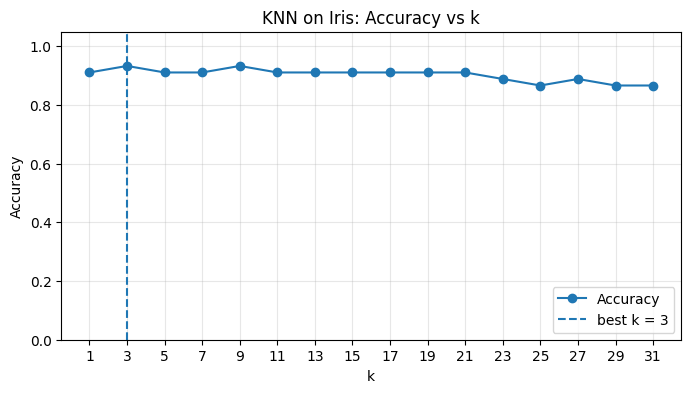

In [39]:
# PRE-WRITTEN
SEED = 42
metric = "manhattan"
print("Using metric:", metric)

# 1) Split
X_train, X_test, y_train, y_test = train_test_split_py(X, y, test_size=0.3, seed=SEED)
print("Split sizes -> train:", len(X_train), "test:", len(X_test))

# 2) Fit min-max on train only, then transform train/test
mins, maxs = minmax_fit(X_train)
X_train_scaled = minmax_transform(X_train, mins, maxs)
X_test_scaled = minmax_transform(X_test, mins, maxs)

print("First train row (raw):", X_train[0])
print("First train row (scaled):", X_train_scaled[0])

# Quick sanity check for scaling range (train set)
min_scaled_value = min(min(row) for row in X_train_scaled)
max_scaled_value = max(max(row) for row in X_train_scaled)
print("Scaled train global min/max:", min_scaled_value, max_scaled_value)

# 3) Try odd k values from 1 to 31
ks = list(range(1, 32, 2))
accuracies = []

print("\nk -> accuracy")
for k in ks:
    y_pred = knn_predict(X_test_scaled, X_train_scaled, y_train, k, metric)
    acc = accuracy(y_test, y_pred)
    accuracies.append(acc)
    print(f"{k:2d} -> {acc:.4f}")

best_index = max(range(len(accuracies)), key=lambda i: accuracies[i])
best_k = ks[best_index]
best_acc = accuracies[best_index]
print(f"\nBest k: {best_k}, best accuracy: {best_acc:.4f}")

# 4) Plot accuracy vs k
plt.figure(figsize=(8, 4))
plt.plot(ks, accuracies, marker="o", label="Accuracy")
plt.title("KNN on Iris: Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(ks)
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.axvline(best_k, linestyle="--", label=f"best k = {best_k}")
plt.legend()
plt.show()

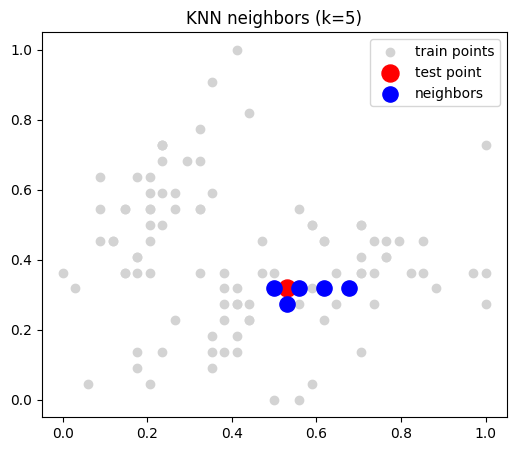

In [40]:
# PRE-WRITTEN
# VISUALIZATION

test_point = X_test_scaled[0]
show_knn_neighbors(
    test_point,
    X_train_scaled,
    y_train,
    k=5,
    metric=metric
)

In [41]:
# PRE-WRITTEN
# SKLEARN COMPARISON
from sklearn.neighbors import KNeighborsClassifier

print("\nComparison with sklearn")
print("Metric used for comparison:", metric)

sk_accuracies = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    model.fit(X_train_scaled, y_train)

    y_pred_sk = model.predict(X_test_scaled)

    acc = accuracy(y_test, y_pred_sk.tolist())
    sk_accuracies.append(acc)

    print(f"sklearn k={k:2d} -> {acc:.4f}")


Comparison with sklearn
Metric used for comparison: manhattan
sklearn k= 1 -> 0.9111
sklearn k= 3 -> 0.9333
sklearn k= 5 -> 0.9111
sklearn k= 7 -> 0.9111
sklearn k= 9 -> 0.9333
sklearn k=11 -> 0.9111
sklearn k=13 -> 0.9111
sklearn k=15 -> 0.9111
sklearn k=17 -> 0.9111
sklearn k=19 -> 0.9111
sklearn k=21 -> 0.9111
sklearn k=23 -> 0.8889
sklearn k=25 -> 0.8667
sklearn k=27 -> 0.8889
sklearn k=29 -> 0.8667
sklearn k=31 -> 0.8667


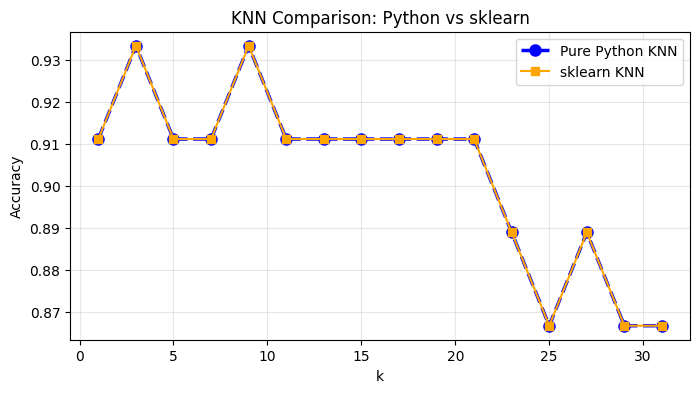

In [42]:
# PRE-WRITTEN
# VISUALIZATION
plt.figure(figsize=(8,4))
plt.plot(
    ks, accuracies, 
    marker="o", color="blue", linestyle="--", 
    linewidth=2.5, markersize=8, 
    label="Pure Python KNN"
)
plt.plot(
    ks, sk_accuracies, 
    marker="s", color="orange", linestyle="-", 
    linewidth=1.5, markersize=6,
    label="sklearn KNN"
)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Comparison: Python vs sklearn")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## F) OPTIONAL Extension (Regression)

Can be skipped in a live session if time is short.

In [43]:
# LIVE CODING (OPTIONAL)
def knn_regress_predict_one(x, X_train, y_train, k):
    """
    Predict one numeric target with KNN regression by averaging the
    targets of the k nearest neighbors (uniform weights).
    """
    distance_target_pairs = []

    for i in range(len(X_train)):
        d = manhattan_distance(x, X_train[i])
        distance_target_pairs.append((d, y_train[i]))

    distance_target_pairs.sort(key=lambda pair: pair[0])
    neighbors = distance_target_pairs[:k]

    total = 0.0
    for d, target in neighbors:
        total += target

    return total / k


def knn_regress_predict(X_test, X_train, y_train, k):
    """
    Predict numeric targets for all rows in X_test.
    """
    preds = []
    for x in X_test:
        preds.append(knn_regress_predict_one(x, X_train, y_train, k))
    return preds


def mae(y_true, y_pred):
    """
    Mean Absolute Error computed from scratch.
    """
    total = 0.0
    for i in range(len(y_true)):
        total += abs(y_true[i] - y_pred[i])
    return total / len(y_true)

**CHECK (after implementation):**
- Regression predictions should be floats.
- MAE should be a non-negative float (lower is better).

In [44]:
# PRE-WRITTEN (OPTIONAL)
Xr, yr = make_regression(
    n_samples=160,
    n_features=4,
    noise=15.0,
    random_state=SEED
)
Xr = Xr.tolist()
yr = yr.tolist()

Xr_train, Xr_test, yr_train, yr_test = train_test_split_py(Xr, yr, test_size=0.25, seed=SEED)

r_mins, r_maxs = minmax_fit(Xr_train)
Xr_train_scaled = minmax_transform(Xr_train, r_mins, r_maxs)
Xr_test_scaled = minmax_transform(Xr_test, r_mins, r_maxs)

print("Regression split -> train:", len(Xr_train), "test:", len(Xr_test))
print("First regression row (raw):", Xr_train[0])
print("First regression row (scaled):", Xr_train_scaled[0])

for k in [3, 5, 7, 9]:
    yr_pred = knn_regress_predict(Xr_test_scaled, Xr_train_scaled, yr_train, k)
    score = mae(yr_test, yr_pred)
    print(f"Regression MAE for k={k}: {score:.4f}")

Regression split -> train: 120 test: 40
First regression row (raw): [0.2320499373576363, -1.4074637743765552, -0.4710383056183228, -1.4480843414973241]
First regression row (scaled): [0.37626283053739223, 0.17810460014625118, 0.3737466368662832, 0.31531157145265126]
Regression MAE for k=3: 33.7260
Regression MAE for k=5: 34.3616
Regression MAE for k=7: 35.4695
Regression MAE for k=9: 34.5154
